<a href="https://colab.research.google.com/github/adityab-tech/Prism/blob/main/W2_Prism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [111]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [112]:
pd.set_option("display.max_columns", None)

# Better plot size
plt.rcParams["figure.figsize"] = (15,5)

In [113]:
df = pd.read_csv(
    "/content/drive/MyDrive/PRISM/raw_data/TCS.NS.csv",
    header=[0,1]
)
df.columns = df.columns.get_level_values(0)

# Remove the first row (which contains "Date")
df = df.iloc[1:].reset_index(drop=True)
df.rename(columns={"Price": "Date"}, inplace=True)

In [114]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2019-01-01,1561.000610,1566.907236,1546.397979,1555.422052,1094883.0
1,2019-01-02,1577.817749,1586.964795,1558.703087,1562.804937,2100463.0
2,2019-01-03,1558.662354,1595.579013,1553.042838,1574.290446,2611668.0
3,2019-01-04,1539.711792,1559.687786,1510.301540,1558.703382,4280862.0
4,2019-01-07,1556.980347,1565.922400,1543.116073,1551.976109,1856423.0


In [115]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True) #setting date as index

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1481 entries, 2019-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1481 non-null   float64
 1   High    1481 non-null   float64
 2   Low     1481 non-null   float64
 3   Open    1481 non-null   float64
 4   Volume  1481 non-null   float64
dtypes: float64(5)
memory usage: 69.4 KB


In [117]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2019-01-01,1561.000610,1566.907236,1546.397979,1555.422052,1094883.0
2019-01-02,1577.817749,1586.964795,1558.703087,1562.804937,2100463.0
2019-01-03,1558.662354,1595.579013,1553.042838,1574.290446,2611668.0
2019-01-04,1539.711792,1559.687786,1510.301540,1558.703382,4280862.0
2019-01-07,1556.980347,1565.922400,1543.116073,1551.976109,1856423.0


In [118]:
df.isnull().sum()

,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [119]:
df.describe()

,Close,High,Low,Open,Volume
count,1481.000000,1481.000000,1481.000000,1481.000000,1.481000e+03
mean,2751.234888,2778.450886,2724.831639,2752.136324,2.745963e+06
std,735.664131,739.792090,731.702866,735.225585,1.660880e+06
min,1403.242554,1445.347957,1282.137060,1337.511764,1.548950e+05
25%,1901.627075,1923.109589,1878.140313,1900.743829,1.711510e+06
50%,2889.345703,2914.741030,2863.072675,2889.963449,2.316539e+06
75%,3231.117920,3254.525623,3205.212637,3234.931844,3.224657e+06
max,4253.906250,4289.871200,4214.905946,4274.691846,1.983933e+07


In [120]:
df.shape

(1481, 5)

In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
df = df.dropna()

In [123]:
df["return"] = df["Close"].pct_change()

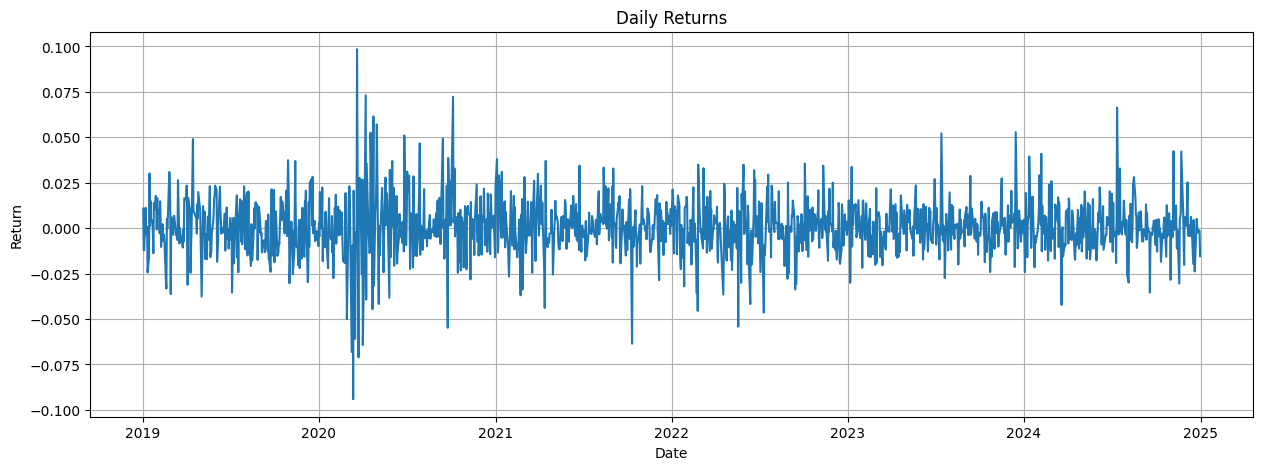

In [124]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["return"])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.show()

In [125]:
df["log_return"] = np.log(      #ts is the most imp concept of how to calculate returns
    df["Close"] /
    df["Close"].shift(1)
)

In [126]:
df[["Close","return"]].head(10)

,Close,return
Date,,
2019-01-01,1561.000610,NaN
2019-01-02,1577.817749,0.010773
2019-01-03,1558.662354,-0.012140
2019-01-04,1539.711792,-0.012158
2019-01-07,1556.980347,0.011215
2019-01-08,1553.412231,-0.002292
2019-01-09,1547.997559,-0.003486
2019-01-10,1549.310303,0.000848
2019-01-11,1511.572998,-0.024357


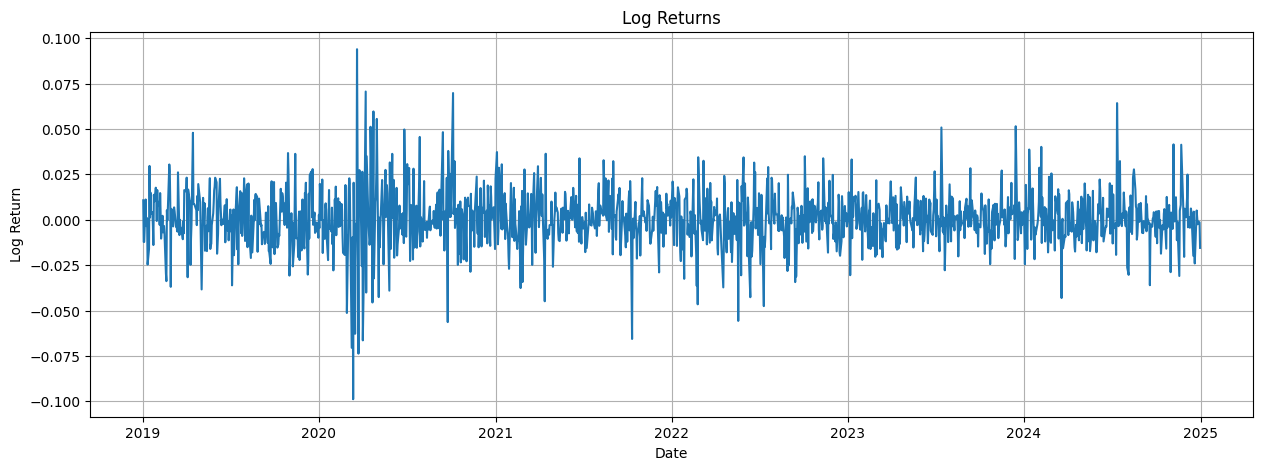

In [127]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["log_return"])
plt.title("Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

In [128]:
print(df[["Close", "return", "log_return"]].head(10))

                  Close    return  log_return
Date                                         
2019-01-01  1561.000610       NaN         NaN
2019-01-02  1577.817749  0.010773    0.010716
2019-01-03  1558.662354 -0.012140   -0.012215
2019-01-04  1539.711792 -0.012158   -0.012233
2019-01-07  1556.980347  0.011215    0.011153
2019-01-08  1553.412231 -0.002292   -0.002294
2019-01-09  1547.997559 -0.003486   -0.003492
2019-01-10  1549.310303  0.000848    0.000848
2019-01-11  1511.572998 -0.024357   -0.024659
2019-01-14  1487.536133 -0.015902   -0.016030


In [129]:
print(df[["return", "log_return"]].describe())

            return   log_return
count  1480.000000  1480.000000
mean      0.000724     0.000607
std       0.015253     0.015250
min      -0.094104    -0.098830
25%      -0.006960    -0.006984
50%       0.000518     0.000518
75%       0.008536     0.008500
max       0.098451     0.093901


In [130]:
df["MA5"] = df["Close"].rolling(window=5).mean()

# 10-Day Moving Average
df["MA10"] = df["Close"].rolling(window=10).mean()

# 20-Day Moving Average
df["MA20"] = df["Close"].rolling(window=20).mean()

In [131]:
# Check
df[["Close", "MA5", "MA10", "MA20"]].head(25)

,Close,MA5,MA10,MA20
Date,,,,
2019-01-01,1561.000610,NaN,NaN,NaN
2019-01-02,1577.817749,NaN,NaN,NaN
2019-01-03,1558.662354,NaN,NaN,NaN
2019-01-04,1539.711792,NaN,NaN,NaN
2019-01-07,1556.980347,1558.834570,NaN,NaN
2019-01-08,1553.412231,1557.316895,NaN,NaN
2019-01-09,1547.997559,1551.352856,NaN,NaN
2019-01-10,1549.310303,1549.482446,NaN,NaN
2019-01-11,1511.572998,1543.854687,NaN,NaN


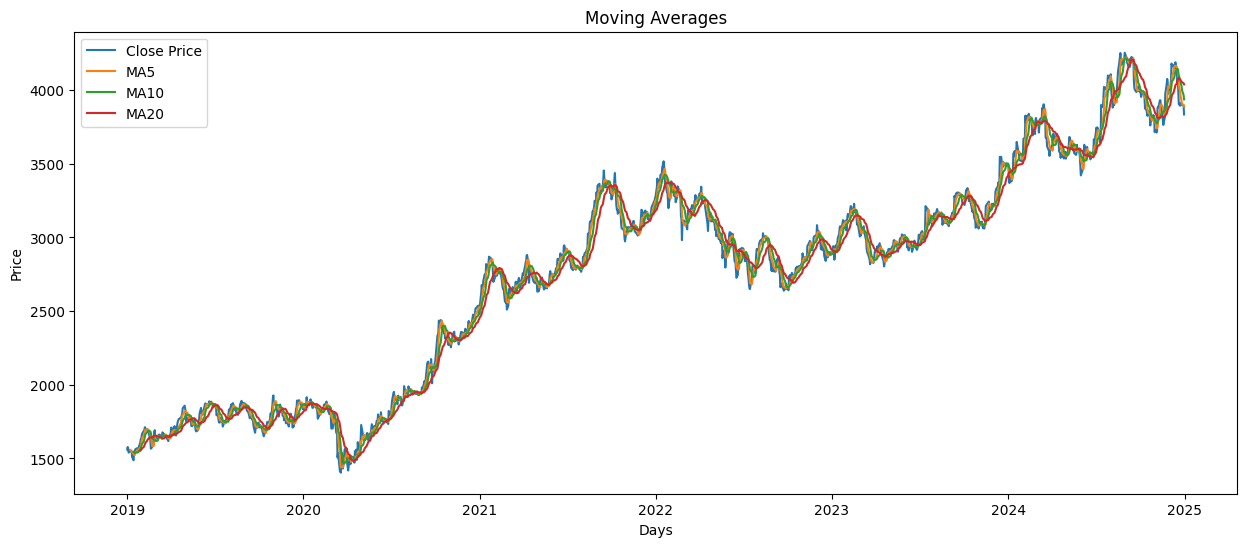

In [132]:
plt.figure(figsize=(15,6))
plt.plot(df["Close"], label="Close Price")
plt.plot(df["MA5"], label="MA5")
plt.plot(df["MA10"], label="MA10")
plt.plot(df["MA20"], label="MA20")
plt.title("Moving Averages")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

In [133]:
# 20-Day Rolling Volatility
df["Volatility"] = df["return"].rolling(window=20).std()

# Check
df[["return", "Volatility"]].head(25)

,return,Volatility
Date,,
2019-01-01,NaN,NaN
2019-01-02,0.010773,NaN
2019-01-03,-0.012140,NaN
2019-01-04,-0.012158,NaN
2019-01-07,0.011215,NaN
2019-01-08,-0.002292,NaN
2019-01-09,-0.003486,NaN
2019-01-10,0.000848,NaN
2019-01-11,-0.024357,NaN


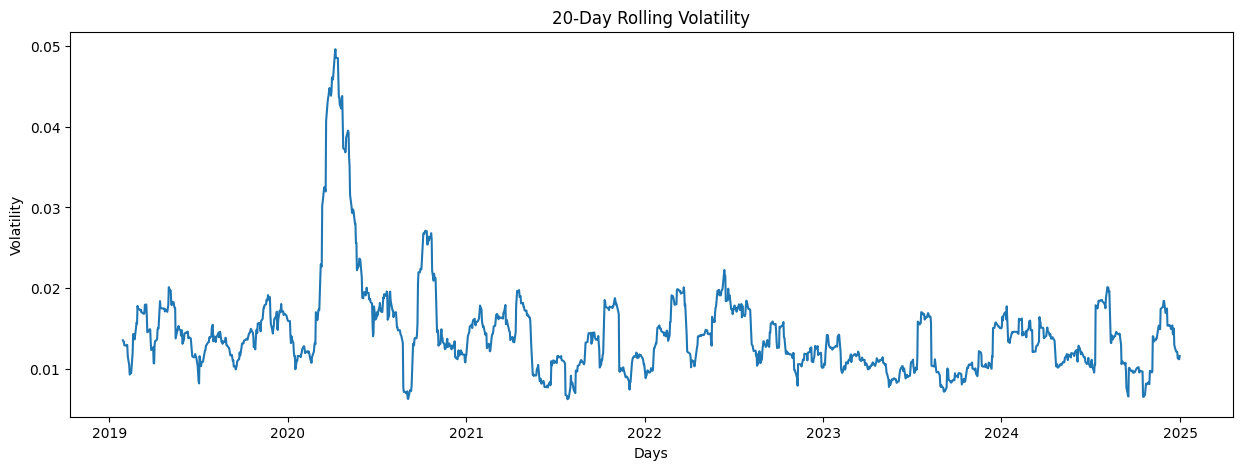

In [134]:
plt.figure(figsize=(15,5))

plt.plot(df["Volatility"])

plt.title("20-Day Rolling Volatility")
plt.xlabel("Days")
plt.ylabel("Volatility")

plt.show()

In [135]:
df["Volume_Change"] = df["Volume"].pct_change()
df["Volume_MA20"] = df["Volume"].rolling(window=20).mean()
df[["Volume", "Volume_Change", "Volume_MA20"]].head(25)

,Volume,Volume_Change,Volume_MA20
Date,,,
2019-01-01,1094883.0,NaN,NaN
2019-01-02,2100463.0,0.918436,NaN
2019-01-03,2611668.0,0.243377,NaN
2019-01-04,4280862.0,0.639129,NaN
2019-01-07,1856423.0,-0.566344,NaN
2019-01-08,1691756.0,-0.088701,NaN
2019-01-09,2414376.0,0.427142,NaN
2019-01-10,3053461.0,0.264700,NaN
2019-01-11,9209862.0,2.016204,NaN


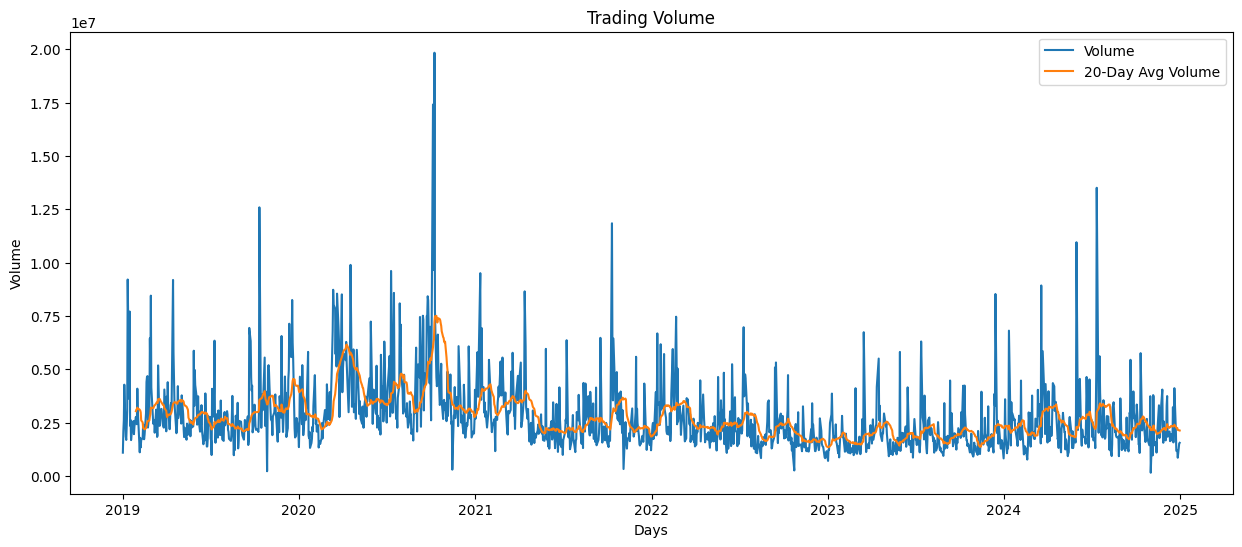

In [136]:
plt.figure(figsize=(15,6))

plt.plot(df["Volume"], label="Volume")
plt.plot(df["Volume_MA20"], label="20-Day Avg Volume")

plt.title("Trading Volume")
plt.xlabel("Days")
plt.ylabel("Volume")

plt.legend()

plt.show()

In [137]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'return', 'log_return', 'MA5',
       'MA10', 'MA20', 'Volatility', 'Volume_Change', 'Volume_MA20'],
      dtype='object')


In [138]:
df.head(25)

,Close,High,Low,Open,Volume,return,log_return,MA5,MA10,MA20,Volatility,Volume_Change,Volume_MA20
Date,,,,,,,,,,,,,
2019-01-01,1561.000610,1566.907236,1546.397979,1555.422052,1094883.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-02,1577.817749,1586.964795,1558.703087,1562.804937,2100463.0,0.010773,0.010716,NaN,NaN,NaN,NaN,0.918436,NaN
2019-01-03,1558.662354,1595.579013,1553.042838,1574.290446,2611668.0,-0.012140,-0.012215,NaN,NaN,NaN,NaN,0.243377,NaN
2019-01-04,1539.711792,1559.687786,1510.301540,1558.703382,4280862.0,-0.012158,-0.012233,NaN,NaN,NaN,NaN,0.639129,NaN
2019-01-07,1556.980347,1565.922400,1543.116073,1551.976109,1856423.0,0.011215,0.011153,1558.834570,NaN,NaN,NaN,-0.566344,NaN
2019-01-08,1553.412231,1563.953970,1545.003436,1563.133600,1691756.0,-0.002292,-0.002294,1557.316895,NaN,NaN,NaN,-0.088701,NaN
2019-01-09,1547.997559,1574.290464,1531.385062,1564.774190,2414376.0,-0.003486,-0.003492,1551.352856,NaN,NaN,NaN,0.427142,NaN
2019-01-10,1549.310303,1562.805354,1535.815152,1550.499800,3053461.0,0.000848,0.000848,1549.482446,NaN,NaN,NaN,0.264700,NaN
2019-01-11,1511.572998,1538.193968,1505.379164,1534.092118,9209862.0,-0.024357,-0.024659,1543.854687,NaN,NaN,NaN,2.016204,NaN


In [139]:
import yfinance as yf

nifty = yf.download(
    "^NSEI",
    start="2019-01-01",
    end="2025-01-01",
    auto_adjust=False
)

nifty.reset_index(inplace=True)

nifty.to_csv(
    "/content/drive/MyDrive/PRISM/raw_data/^NSEI.csv",
    index=False
)

[*********************100%***********************]  1 of 1 completed


In [140]:
nifty = pd.read_csv("/content/drive/MyDrive/PRISM/raw_data/^NSEI.csv")

In [141]:
nifty = nifty.iloc[1:].reset_index(drop=True)

In [142]:
nifty.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2019-01-02,10792.5,10792.5,10895.349609375,10735.0498046875,10868.849609375,309700
1,2019-01-03,10672.25,10672.25,10814.0498046875,10661.25,10796.7998046875,286200
2,2019-01-04,10727.349609375,10727.349609375,10741.0498046875,10628.650390625,10699.7001953125,296600
3,2019-01-07,10771.7998046875,10771.7998046875,10835.9501953125,10750.150390625,10804.849609375,269400
4,2019-01-08,10802.150390625,10802.150390625,10818.4501953125,10733.25,10786.25,277700


In [143]:
nifty["Date"] = pd.to_datetime(nifty["Date"])

In [144]:
print(nifty.dtypes)

Date         datetime64[ns]
Adj Close            object
Close                object
High                 object
Low                  object
Open                 object
Volume               object
dtype: object


In [145]:
nifty["Close"] = pd.to_numeric(nifty["Close"], errors="coerce")      #converting object into float64

In [146]:
nifty["market_return"] = nifty["Close"].pct_change()

In [147]:
nifty = nifty[["Date", "market_return"]]

In [148]:
df = pd.merge(
    df,
    nifty,
    on="Date",
    how="inner"
)

In [149]:
covariance = (
    df["return"]
    .rolling(60)
    .cov(df["market_return"])
)

variance = (
    df["market_return"]
    .rolling(60)
    .var()
)

df["beta"] = covariance / variance

In [150]:
df[["return","market_return","beta"]].tail()

,return,market_return,beta
1473,0.005098,-0.001086,0.986706
1474,-0.002488,0.000950,0.983656
1475,-0.001019,0.002661,0.989640
1476,-0.001453,-0.007076,0.982380
1477,-0.015389,-0.000004,1.016131


In [151]:
df["beta"].describe()

,beta
count,1418.000000
mean,0.712282
std,0.279786
min,-0.154947
25%,0.571876
50%,0.749856
75%,0.910398
max,1.298479


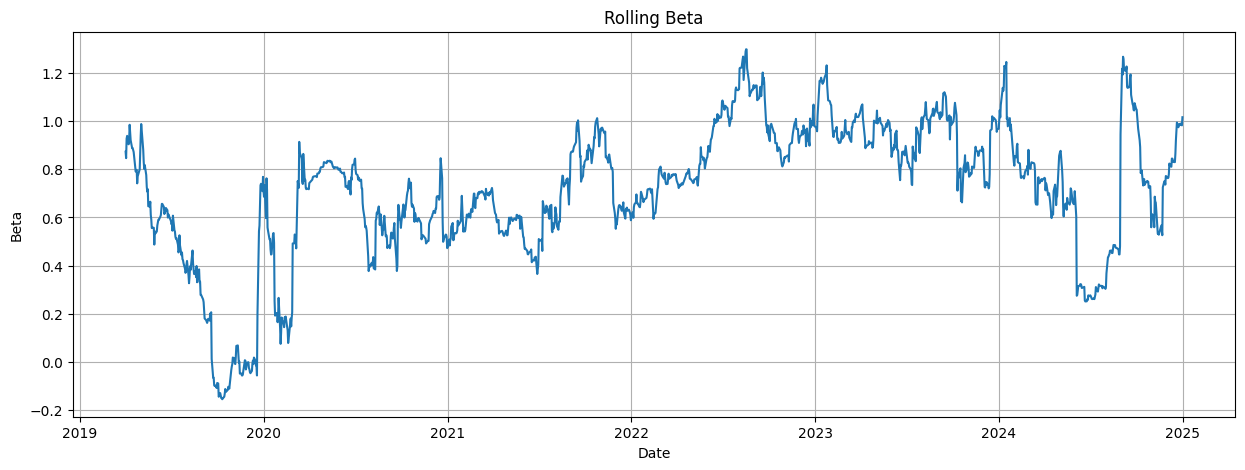

In [152]:
plt.figure(figsize=(15,5))
plt.plot(df["Date"], df["beta"])
plt.title("Rolling Beta")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.grid(True)
plt.show()

In [153]:
df["target"] = df["return"].shift(-1)

In [154]:
df[["return","target"]].head(10)

,return,target
0,0.010773,-0.012140
1,-0.012140,-0.012158
2,-0.012158,0.011215
3,0.011215,-0.002292
4,-0.002292,-0.003486
5,-0.003486,0.000848
6,0.000848,-0.024357
7,-0.024357,-0.015902
8,-0.015902,0.030084
9,0.030084,0.001258


In [155]:
df.dropna(inplace=True) #as my last row has no tomorrow kyuki ghee khtm

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1417 entries, 60 to 1476
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1417 non-null   datetime64[ns]
 1   Close          1417 non-null   float64       
 2   High           1417 non-null   float64       
 3   Low            1417 non-null   float64       
 4   Open           1417 non-null   float64       
 5   Volume         1417 non-null   float64       
 6   return         1417 non-null   float64       
 7   log_return     1417 non-null   float64       
 8   MA5            1417 non-null   float64       
 9   MA10           1417 non-null   float64       
 10  MA20           1417 non-null   float64       
 11  Volatility     1417 non-null   float64       
 12  Volume_Change  1417 non-null   float64       
 13  Volume_MA20    1417 non-null   float64       
 14  market_return  1417 non-null   float64       
 15  beta           1417 non-n

In [157]:
df.tail()

,Date,Close,High,Low,Open,Volume,return,log_return,MA5,MA10,MA20,Volatility,Volume_Change,Volume_MA20,market_return,beta,target
1472,2024-12-23,3893.971191,3948.940020,3853.330069,3933.067290,2195338.0,-0.002878,-0.002882,3984.871191,4071.697363,4072.427808,0.012251,-0.466761,2310755.70,0.007035,0.974479,0.005098
1473,2024-12-24,3913.823975,3949.876666,3893.971401,3893.971401,1181886.0,0.005098,0.005085,3956.965479,4048.000903,4064.318250,0.012114,-0.461638,2266816.55,-0.001086,0.986706,-0.002488
1474,2024-12-26,3904.085205,3932.974272,3879.784572,3913.824023,1208464.0,-0.002488,-0.002491,3923.487939,4023.808105,4056.665271,0.012099,0.022488,2249290.10,0.000950,0.983656,-0.001019
1475,2024-12-27,3900.105469,3915.182141,3883.624146,3898.372975,858100.0,-0.001019,-0.001020,3903.438916,3996.642236,4052.917212,0.011299,-0.289925,2164267.90,0.002661,0.989640,-0.001453
1476,2024-12-30,3894.439453,3932.365010,3850.614548,3887.135455,1527169.0,-0.001453,-0.001454,3901.285059,3967.135156,4047.670825,0.011178,0.779710,2139755.10,-0.007076,0.982380,-0.015389


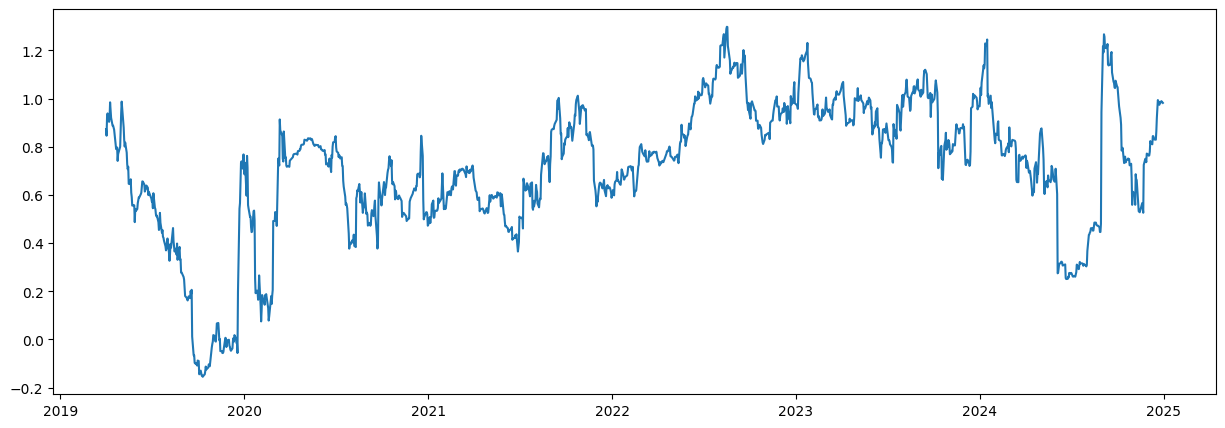

In [158]:
plt.plot(df["Date"], df["beta"])

In [161]:
features = ["return","log_return","MA5","MA10","MA20","Volatility","Volume_Change","Volume_MA20","market_return","beta","target"]
corr = df[features].corr()
corr

,return,log_return,MA5,MA10,MA20,Volatility,Volume_Change,Volume_MA20,market_return,beta,target
return,1.000000,0.999805,-0.028083,-0.032135,-0.033689,0.017598,0.031052,0.040563,0.543053,-0.028651,-0.030688
log_return,0.999805,1.000000,-0.024857,-0.028969,-0.030615,0.009838,0.026888,0.036306,0.545308,-0.028762,-0.030148
MA5,-0.028083,-0.024857,1.000000,0.998698,0.994674,-0.374438,-0.001639,-0.483999,-0.001589,0.393508,-0.037811
MA10,-0.032135,-0.028969,0.998698,1.000000,0.997674,-0.374605,-0.001649,-0.487300,-0.005064,0.397194,-0.036610
MA20,-0.033689,-0.030615,0.994674,0.997674,1.000000,-0.374354,-0.000840,-0.494060,-0.007074,0.400687,-0.035826
Volatility,0.017598,0.009838,-0.374438,-0.374605,-0.374354,1.000000,-0.007374,0.704002,0.001925,-0.002687,0.015640
Volume_Change,0.031052,0.026888,-0.001639,-0.001649,-0.000840,-0.007374,1.000000,0.000446,-0.005138,-0.045814,0.044179
Volume_MA20,0.040563,0.036306,-0.483999,-0.487300,-0.494060,0.704002,0.000446,1.000000,0.031907,-0.305371,0.037361
market_return,0.543053,0.545308,-0.001589,-0.005064,-0.007074,0.001925,-0.005138,0.031907,1.000000,-0.016500,-0.021252
beta,-0.028651,-0.028762,0.393508,0.397194,0.400687,-0.002687,-0.045814,-0.305371,-0.016500,1.000000,-0.025941


In [162]:
import seaborn as sns

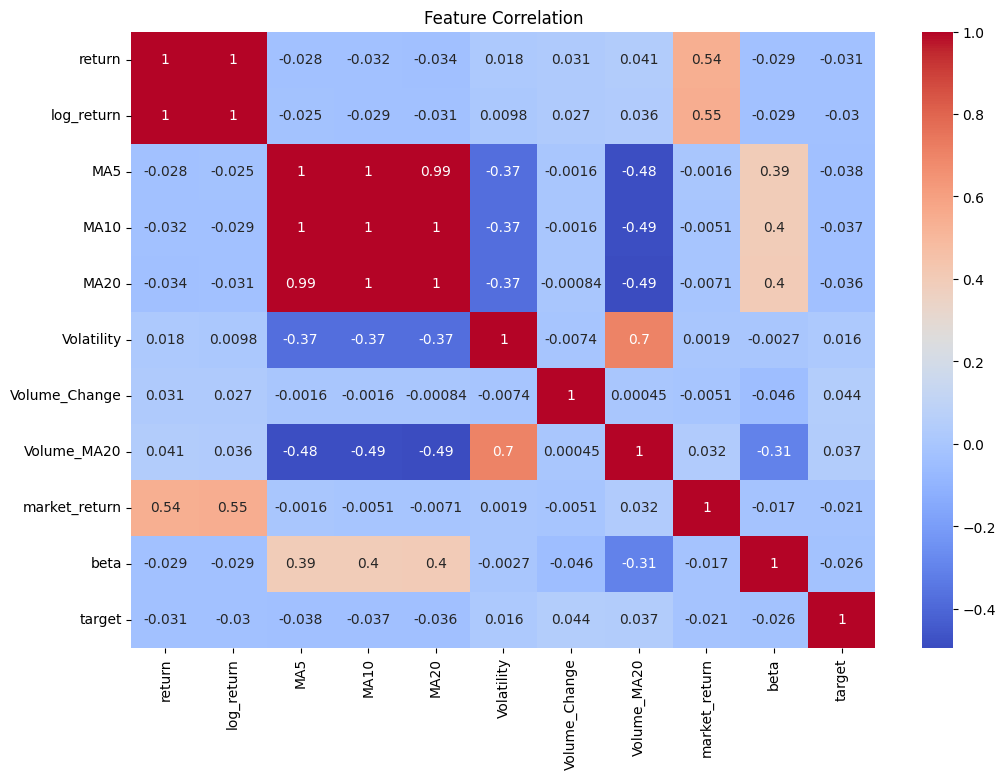

In [163]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()